In [1]:
import xarray as xr
import numpy as np
import glob as glob
import functions
import matplotlib.pyplot as plt
import seaborn as sns
import cmcrameri

In [2]:
# Definitions
Arctic_lim = 60
tslice = slice('2040-01-01','2069-12-31')
lons = slice(0,300)

In [3]:
# Load data clm data
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/land_vars/'
ds_piClim_clm = xr.open_dataset(rpath+'clm_piClim.nc')
ds_2xCO2_clm = xr.open_dataset(rpath+'clm_2xCO2.nc')
ds_4xCO2_clm = xr.open_dataset(rpath+'clm_4xCO2.nc')

# Select timeslice
ds_piClim_clm = ds_piClim_clm.sel(time=tslice)[['area','FSOILSAT_20CM','FSNO','QFLX_EVAP_TOT', 'QRUNOFF','PRECIP_TOTAL']]
ds_2xCO2_clm = ds_2xCO2_clm.sel(time=tslice)[['area','FSOILSAT_20CM','FSNO','QFLX_EVAP_TOT', 'QRUNOFF','PRECIP_TOTAL']]
ds_4xCO2_clm = ds_4xCO2_clm.sel(time=tslice)[['area','FSOILSAT_20CM','FSNO','QFLX_EVAP_TOT', 'QRUNOFF','PRECIP_TOTAL']]

In [4]:
# Load atmospheric data
### RELATIVE HUMIDITY ###

rpath= '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'

landmask = xr.open_dataarray(rpath+'LANDFRAC_piClim.nc')
landmask = landmask.isel(time=0)
oceanmask = 1-landmask
landmask = landmask > 0.8

ds_piClim_cam = xr.open_mfdataset([rpath+'RELHUM_piClim.nc', rpath+'CLDLOW_piClim.nc'])
ds_2xCO2_cam = xr.open_mfdataset([rpath+'RELHUM_abrupt-2xCO2.nc', rpath+'CLDLOW_abrupt-2xCO2.nc'])
ds_4xCO2_cam = xr.open_mfdataset([rpath+'RELHUM_abrupt-4xCO2.nc', rpath+'CLDLOW_abrupt-4xCO2.nc'])

lev = ds_piClim_cam.lev[-1] # Select lowest atmospheric level for relative humidity

ds_piClim_cam = ds_piClim_cam.sel(lev=lev, time=tslice)
ds_2xCO2_cam = ds_2xCO2_cam.sel(lev=lev, time=tslice)
ds_4xCO2_cam = ds_4xCO2_cam.sel(lev=lev, time=tslice)

## Calculate spatial average

In [5]:
area_weights = ds_piClim_clm['area'].sel(lat=slice(Arctic_lim,90),lon=lons)/(ds_piClim_clm['area'].sel(lat=slice(Arctic_lim,90),lon=lons).sum())

ds_piClim_clm_avg = (ds_piClim_clm.sel(lat=slice(Arctic_lim, 90), lon=lons)*area_weights).sum(dim=['lon','lat'])
ds_2xCO2_clm_avg = (ds_2xCO2_clm.sel(lat=slice(Arctic_lim, 90), lon=lons)*area_weights).sum(dim=['lon','lat'])
ds_4xCO2_clm_avg = (ds_4xCO2_clm.sel(lat=slice(Arctic_lim, 90), lon=lons)*area_weights).sum(dim=['lon','lat'])

ds_piClim_cam_lnd = functions.computeWeightedMeanMasked(ds_piClim_cam.sel(lat=slice(Arctic_lim, 90), lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))
ds_2xCO2_cam_lnd = functions.computeWeightedMeanMasked(ds_2xCO2_cam.sel(lat=slice(Arctic_lim, 90),lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))
ds_4xCO2_cam_lnd = functions.computeWeightedMeanMasked(ds_4xCO2_cam.sel(lat=slice(Arctic_lim, 90), lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))

ds_piClim = xr.merge([ds_piClim_clm_avg, ds_piClim_cam_lnd])
ds_2xCO2 = xr.merge([ds_2xCO2_clm_avg, ds_2xCO2_cam_lnd])
ds_4xCO2 = xr.merge([ds_4xCO2_clm_avg, ds_4xCO2_cam_lnd])

In [6]:
# Monthly averages

ds_piClim_m = ds_piClim.groupby(ds_piClim.time.dt.month).mean('time')
ds_2xCO2_m = ds_2xCO2.groupby(ds_2xCO2.time.dt.month).mean('time')
ds_4xCO2_m = ds_4xCO2.groupby(ds_4xCO2.time.dt.month).mean('time')

ds_piClim_std = ds_piClim.groupby(ds_piClim.time.dt.month).std('time')
ds_2xCO2_std = ds_2xCO2.groupby(ds_2xCO2.time.dt.month).std('time')
ds_4xCO2_std = ds_4xCO2.groupby(ds_4xCO2.time.dt.month).std('time')


<>:74: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:75: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:104: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:74: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:75: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:104: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_394244/1398068317.py:74: SyntaxWarning: "\p" is an invalid 

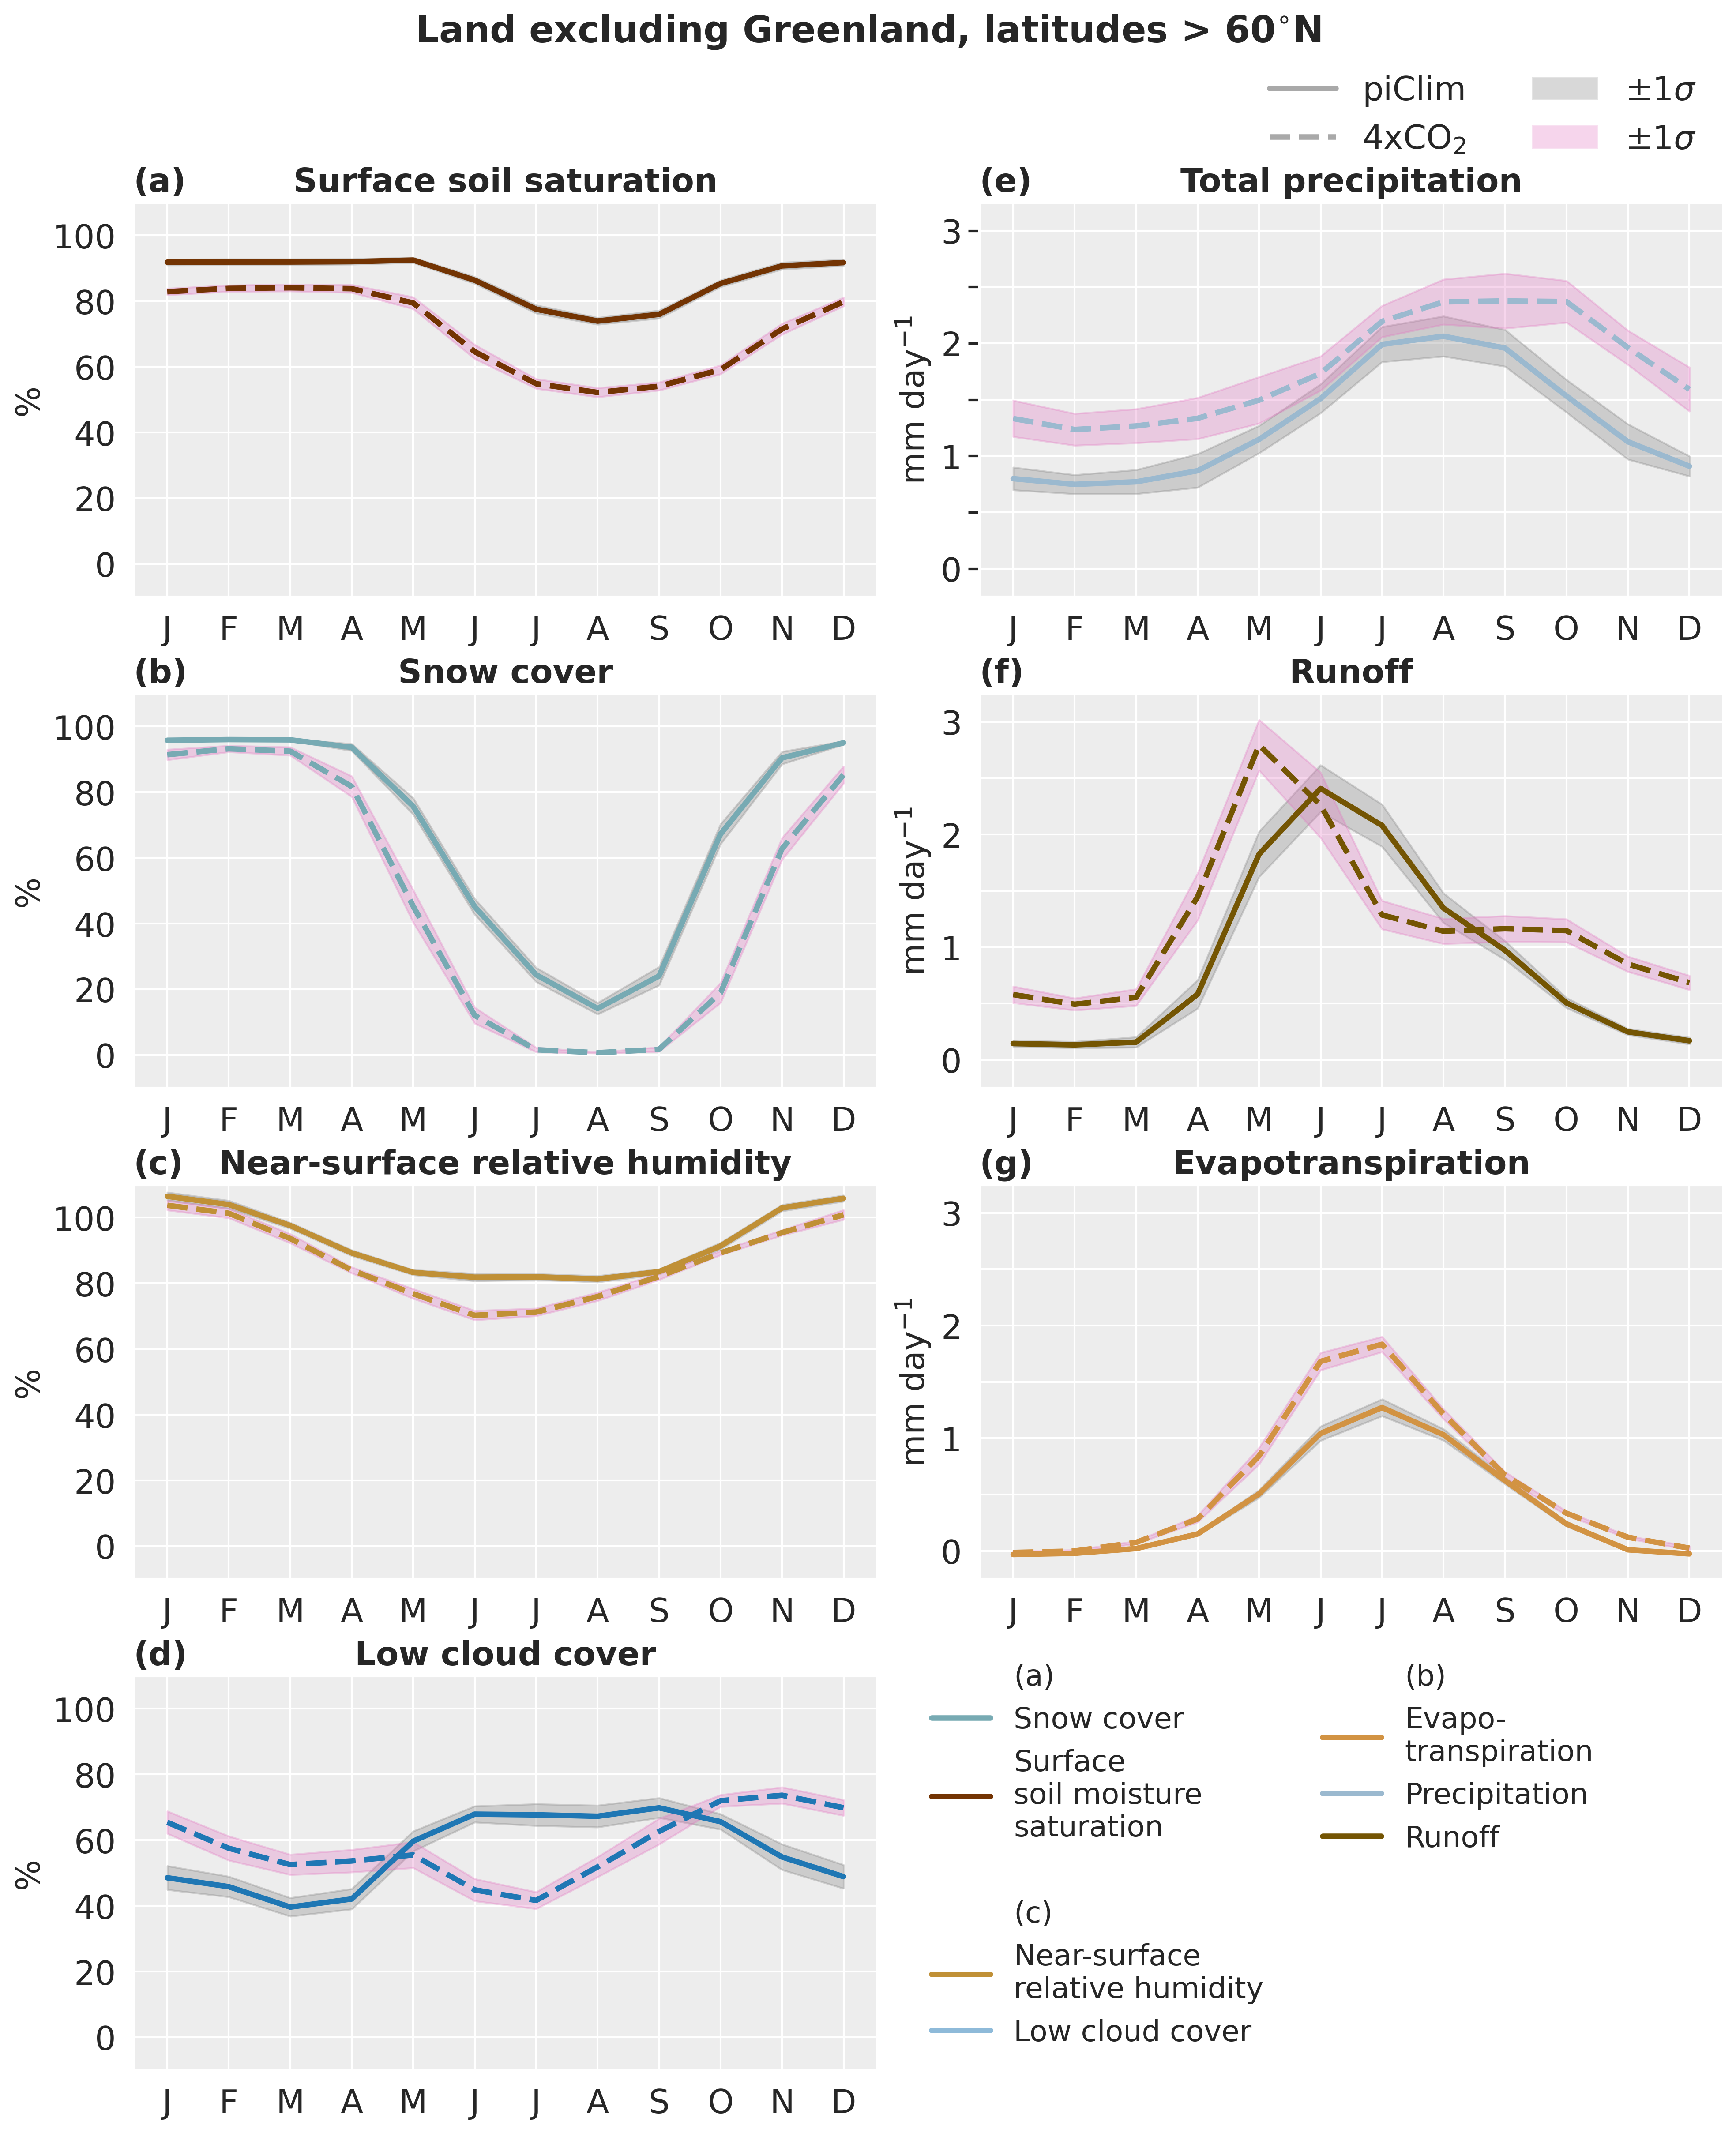

In [8]:
sns.set_theme()
sns.set_style('darkgrid', {'axes.facecolor':'.93'})

months = np.arange(1, 13, 1)
monthnames = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

# Colors

SM_color = cmcrameri.cm.glasgow.colors[70]
SC_color = cmcrameri.cm.glasgow.colors[200]

SRH_color = cmcrameri.cm.batlow.colors[160]
LCC_color = 'tab:blue'

ET_color = cmcrameri.cm.batlow.colors[170]
P_color = cmcrameri.cm.glasgow.colors[220]
R_color = cmcrameri.cm.glasgow.colors[100]

labels = [['(a)','(e)'],['(b)','(f)'], ['(c)','(g)'], ['(d)', ' ']]
lw=3

fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(13, 16),dpi=300,constrained_layout=True)

label = ' '
ax = axs[label]
ax.axis('off')

label_list = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']
var_list = ['FSOILSAT_20CM', 'FSNO', 'RELHUM', 'CLDLOW', 'PRECIP_TOTAL','QRUNOFF','QFLX_EVAP_TOT']
color_list = [SM_color, SC_color, SRH_color, LCC_color, P_color, R_color, ET_color]
sim_colors = ['grey', 'tab:pink']
title_list = ['Surface soil saturation', 'Snow cover', 'Near-surface relative humidity', 'Low cloud cover', 
              'Total precipitation', 'Runoff', 'Evapotranspiration']
# (a)
for label, var, c, title in zip(label_list, var_list, color_list, title_list):
    ax = axs[label]
    for ds, ds_std, ls, sim_c in zip([ds_piClim_m, ds_4xCO2_m], [ds_piClim_std, ds_4xCO2_std], ['-','--'], sim_colors):

        if var in ['FSOILSAT_20CM', 'FSNO', 'CLDLOW']:
            conversion_factor = 100 # fraction to percent
        elif var in ['PRECIP_TOTAL','QRUNOFF','QFLX_EVAP_TOT']:
            conversion_factor = 60*60*24 # mm/s to mm/day
        else:
            conversion_factor = 1
        data = ds[var]*conversion_factor
        std = ds_std[var]*conversion_factor
        ax.fill_between(months, data-std, data+std, color=sim_c, alpha=0.3)
        ax.plot(months, data, color=c, linestyle=ls, lw=lw,zorder=10)
        
    ax.set_title(title, fontsize=18,fontweight='bold')

    if var in ['PRECIP_TOTAL','QRUNOFF','QFLX_EVAP_TOT']:
        ax.set_ylim([-0.25,3.25])
        ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
        ax.set_yticklabels([0, '', 1, '', 2, '', 3], fontsize=18)
        #ax.tick_params(axis='y', length=0.00001)
        ax.set_ylabel('mm day$^{-1}$', fontsize=18)
    else:
        ax.set_ylim([-10,110])
        ax.set_yticks([0, 20, 40, 60, 80, 100])
        ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=18)
        ax.set_ylabel('%', fontsize=18)

    ax.set_xticks(months)
    ax.set_xticklabels(monthnames, fontsize=18)



from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements_0 = [Line2D([0], [0], color='darkgrey', lw=lw, linestyle='-', label='piClim'),
                Line2D([0], [0], color='darkgrey', lw=lw, linestyle='--', label='4xCO$_2$'),
                Patch(facecolor=sim_colors[0], edgecolor=None, alpha=0.3, label='$\pm$1$\sigma$'),
                Patch(facecolor=sim_colors[1], edgecolor=None, alpha=0.3, label='$\pm$1$\sigma$')]


legend_elements_all = [
                Patch(visible=False,label= '(a)'),
                Line2D([0], [0], color=SC_color, lw=lw, linestyle='-', label='Snow cover'),
                Line2D([0], [0], color=SM_color, lw=lw, linestyle='-', label='Surface\nsoil moisture\nsaturation'),
                Patch(visible=False,label= ' '),
                Patch(visible=False,label= '(c)'),
                Line2D([0], [0], color=SRH_color, lw=lw, linestyle='-', label='Near-surface\nrelative humidity'),
                Line2D([0], [0], color=LCC_color, lw=lw, linestyle='-', alpha=0.5,label='Low cloud cover'),
                Patch(visible=False,label= '(b)'),
                Line2D([0], [0], color=ET_color, lw=lw, linestyle='-', label='Evapo-\ntranspiration'),
                Line2D([0], [0], color=P_color, lw=lw, linestyle='-', label='Precipitation'),
                Line2D([0], [0], color=R_color, lw=lw, linestyle='-', label='Runoff'),
                Patch(visible=False,label= ' '),
                Patch(visible=False,label= ' '),]

ax1 = axs['(e)'].twinx()
ax1.legend(handles=legend_elements_0, loc='upper left', bbox_to_anchor=(0.35, 1.40),frameon=False,
                fontsize=18,title_fontsize=18,ncols=2)
ax1.get_yaxis().set_visible(False)

axs[' '].legend(handles=legend_elements_all, loc='upper left', bbox_to_anchor=(-0.1, 1.1),frameon=False,
                fontsize=16,title_fontsize=16,ncols=2)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
fig.suptitle('Land excluding Greenland, latitudes > 60$^{\circ}$N',fontsize=20,fontweight='bold')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA4.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA4.pdf',bbox_inches='tight')

plt.show()